# Simulation BMS — Drone Agricole Solaire
## Batterie Li-ion 4S2P · 14.8 V · 10 Ah · 148 Wh
### Modèle ECM 1RC (Thévenin) — Mission 50 minutes

---
**Contenu :**
1. Paramètres du modèle batterie
2. Profil de mission (4 phases)
3. Simulation de décharge (batterie seule)
4. Simulation avec assistance solaire + MPPT
5. Simulation de recharge
6. Visualisation complète (SoC, tension, puissance, courant)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d


plt.rcParams.update({
    'figure.facecolor': '#F8F9FA',
    'axes.facecolor': '#FFFFFF',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
print("✅ Bibliothèques chargées avec succès")

✅ Bibliothèques chargées avec succès


---
## 1. Paramètres du modèle ECM 1RC

In [2]:
# ============================================================
# PARAMÈTRES BATTERIE Li-ion 4S2P
# ============================================================

# Configuration
N_series   = 4        # Cellules en série
N_parallel = 2        # Branches en parallèle

# Caractéristiques électriques
V_nom      = 14.8     # Tension nominale [V]
V_max      = 16.8     # Tension max (4.2 V/cellule × 4)
V_min      = 12.0     # Tension min (3.0 V/cellule × 4)
Q_nom      = 10.0     # Capacité nominale [Ah]
E_nom      = V_nom * Q_nom  # Énergie [Wh]

# Paramètres ECM 1RC
R0 = 0.050            # Résistance série [Ω]
R1 = 0.010            # Résistance RC [Ω]
C1 = 2000.0           # Capacité RC [F]
tau1 = R1 * C1        # Constante de temps [s]

# Table OCV vs SoC (interpolée)
SoC_table = np.array([0.0, 0.1, 0.2, 0.3, 0.4, 0.5,
                       0.6, 0.7, 0.8, 0.9, 1.0])
OCV_table = np.array([12.0, 12.8, 13.2, 13.6, 13.9, 14.2,
                       14.5, 14.8, 15.2, 15.8, 16.8])  # V (4S)

# Interpolation OCV(SoC)
OCV_interp = interp1d(SoC_table, OCV_table, kind='cubic',
                       bounds_error=False, fill_value=(12.0, 16.8))

print(f"Batterie : {N_series}S{N_parallel}P")
print(f"  Tension nominale : {V_nom} V")
print(f"  Capacité         : {Q_nom} Ah")
print(f"  Énergie          : {E_nom:.1f} Wh")
print(f"  R0={R0*1000:.0f} mΩ  R1={R1*1000:.0f} mΩ  C1={C1:.0f} F  τ={tau1:.0f} s")

Batterie : 4S2P
  Tension nominale : 14.8 V
  Capacité         : 10.0 Ah
  Énergie          : 148.0 Wh
  R0=50 mΩ  R1=10 mΩ  C1=2000 F  τ=20 s


---
## 2. Profil de mission (4 phases de vol)

In [3]:
# ============================================================
# PROFIL DE MISSION
# ============================================================

# [Phase, durée_s, puissance_W, label]
phases = [
    ('Décollage',  3*60,  120.0, '🛫'),
    ('Montée',     5*60,   90.0, '📈'),
    ('Croisière', 37*60,   55.0, '✈️'),
    ('Retour',     5*60,   65.0, '🛬'),
]

# Construction du profil temporel (pas dt = 1 s)
dt = 1.0  # [s]
t_total = sum(p[1] for p in phases)
t_arr   = np.arange(0, t_total, dt)
P_drone = np.zeros(len(t_arr))   # Puissance consommée par le drone [W]
phase_label = np.empty(len(t_arr), dtype=object)

t_cursor = 0
for name, duration, power, icon in phases:
    idx = (t_arr >= t_cursor) & (t_arr < t_cursor + duration)
    P_drone[idx] = power
    phase_label[idx] = name
    t_cursor += duration

# Affichage résumé
print("Profil de mission :")
print(f"{'Phase':<12} {'Durée (min)':>12} {'Puissance (W)':>14} {'Énergie (Wh)':>13}")
print("-" * 55)
total_E = 0
for name, dur, pwr, _ in phases:
    e = pwr * dur / 3600
    total_E += e
    print(f"{name:<12} {dur/60:>12.0f} {pwr:>14.0f} {e:>13.1f}")
print("-" * 55)
print(f"{'TOTAL':<12} {t_total/60:>12.0f} {'—':>14} {total_E:>13.1f}")
print(f"\nSoC consommé estimé : {total_E/E_nom*100:.1f} %")

Profil de mission :
Phase         Durée (min)  Puissance (W)  Énergie (Wh)
-------------------------------------------------------
Décollage               3            120           6.0
Montée                  5             90           7.5
Croisière              37             55          33.9
Retour                  5             65           5.4
-------------------------------------------------------
TOTAL                  50              —          52.8

SoC consommé estimé : 35.7 %


---
## 3. Modèle ECM 1RC — Simulation de décharge (batterie seule)

In [4]:
# ============================================================
# FONCTION DE SIMULATION ECM 1RC
# ============================================================

def simulate_ECM(t_arr, P_load, SoC_init=1.0, solar_profile=None):
    """
    Simulation du modèle ECM 1RC.
    
    Paramètres:
    -----------
    t_arr        : vecteur temps [s]
    P_load       : puissance consommée [W] (vecteur)
    SoC_init     : SoC initial (0 à 1)
    solar_profile: puissance solaire injectée [W] (vecteur ou None)
    
    Retourne:
    ---------
    dict : SoC, V_bat, I_bat, V_OCV, V_RC, P_bat, P_solar
    """
    n = len(t_arr)
    dt = t_arr[1] - t_arr[0]
    
    # Vecteurs de sortie
    SoC   = np.zeros(n)
    V_bat = np.zeros(n)
    I_bat = np.zeros(n)
    V_OCV = np.zeros(n)
    V_RC  = np.zeros(n)   # Tension sur R1C1
    P_bat = np.zeros(n)
    P_sol = np.zeros(n)
    
    # Initialisation
    SoC[0]   = SoC_init
    V_OCV[0] = float(OCV_interp(SoC_init))
    V_RC[0]  = 0.0
    
    Q_nom_C = Q_nom * 3600  # Ah → Coulombs
    
    if solar_profile is None:
        solar_profile = np.zeros(n)
    
    for k in range(n):
        # Puissance nette sur batterie (après solaire)
        P_sol[k] = min(solar_profile[k], P_load[k])  # MPPT limité à la conso
        P_bat[k] = P_load[k] - P_sol[k]
        
        # Tension OCV
        ocv = float(OCV_interp(np.clip(SoC[k], 0, 1)))
        V_OCV[k] = ocv
        
        # Courant batterie (résolution quadratique: P = V_bat * I)
        # V_bat = OCV - R0*I - V_RC → P = (OCV - R0*I - V_RC)*I
        # R0*I^2 - (OCV - V_RC)*I + P = 0
        a = R0
        b = -(ocv - V_RC[k])
        c = P_bat[k]
        discriminant = b**2 - 4*a*c
        if discriminant < 0:
            discriminant = 0  # Clamp (ne devrait pas arriver si tension > V_min)
        I = (-b - np.sqrt(discriminant)) / (2*a)  # Racine physique
        I_bat[k] = I
        
        # Tension batterie
        V_bat[k] = ocv - R0*I - V_RC[k]
        
        # Mise à jour pour le pas suivant
        if k < n-1:
            # Dynamique RC (Euler)
            dV_RC = (I/C1 - V_RC[k]/(R1*C1)) * dt
            V_RC[k+1] = V_RC[k] + dV_RC
            
            # Coulomb counting (SoC)
            SoC[k+1] = SoC[k] - (I * dt) / Q_nom_C
            SoC[k+1] = np.clip(SoC[k+1], 0.0, 1.0)
            
            # Arrêt si tension critique
            if V_bat[k] < V_min:
                SoC[k+1:] = SoC[k+1]
                V_bat[k+1:] = V_min
                print(f"⚠️  Tension critique atteinte à t={t_arr[k]/60:.1f} min")
                break
    
    return {
        'SoC': SoC * 100,  # en %
        'V_bat': V_bat,
        'I_bat': I_bat,
        'V_OCV': V_OCV,
        'V_RC': V_RC,
        'P_bat': P_bat,
        'P_solar': P_sol,
    }

print("✅ Fonction ECM 1RC définie")

✅ Fonction ECM 1RC définie


In [5]:
# ============================================================
# SIMULATION 1 : DÉCHARGE — BATTERIE SEULE (sans solaire)
# ============================================================

res_discharge = simulate_ECM(t_arr, P_drone, SoC_init=1.0, solar_profile=None)
t_min = t_arr / 60

# Énergie consommée totale
E_consommee = np.trapezoid(res_discharge['P_bat'], t_arr) / 3600
SoC_final   = res_discharge['SoC'][-1]

print(f"Résultats simulation décharge (batterie seule) :")
print(f"  SoC initial  : 100.0 %")
print(f"  SoC final    : {SoC_final:.1f} %")
print(f"  ΔSoC         : {100-SoC_final:.1f} %")
print(f"  Énergie utilisée : {E_consommee:.1f} Wh / {E_nom:.1f} Wh")
print(f"  Courant max  : {res_discharge['I_bat'].max():.2f} A")
print(f"  Tension min  : {res_discharge['V_bat'].min():.2f} V")

Résultats simulation décharge (batterie seule) :
  SoC initial  : 100.0 %
  SoC final    : 65.2 %
  ΔSoC         : 34.8 %
  Énergie utilisée : 52.8 Wh / 148.0 Wh
  Courant max  : 7.54 A
  Tension min  : 14.38 V


---
## 4. Simulation avec assistance solaire + MPPT P&O

In [6]:
# ============================================================
# PROFIL SOLAIRE RÉALISTE + MPPT P&O
# ============================================================

# Paramètres panneau
A_panel  = 0.42    # Surface utile [m²]
eta_panel = 0.20   # Rendement cellules
eta_mppt  = 0.95   # Rendement convertisseur MPPT

# Profil d'irradiance simulé (mission de matin à midi)
# Mission de 0 à 50 min → irradiance croissante
G_min = 400   # W/m² (début de matinée)
G_max = 850   # W/m² (fin de mission vers midi)
G_profile = np.linspace(G_min, G_max, len(t_arr))  # Rampe linéaire
# Ajout d'un léger nuage en milieu de croisière
nuage_mask = (t_arr > 1500) & (t_arr < 1800)
G_profile[nuage_mask] *= 0.5

# ============================================================
# ALGORITHME MPPT Perturbe & Observe (P&O)
# ============================================================
def mppt_P_and_O(G_profile, dt=1.0, dV=0.1, V_init=None):
    """
    Simulation de l'algorithme MPPT P&O.
    Retourne la puissance extraite à chaque instant.
    """
    n = len(G_profile)
    V_mpp_est = np.zeros(n)  # Tension MPP estimée (relative, en p.u.)
    P_mppt    = np.zeros(n)
    
    # V_oc et I_sc à STC
    V_oc_STC = 21.0   # V open circuit (panneau 18V)
    I_sc_STC = 4.8    # A court-circuit
    
    V_ref = 0.75 * V_oc_STC  # Point de départ (≈ 75% Voc)
    V_prev = V_ref
    P_prev = 0.0
    
    for k in range(n):
        G = G_profile[k]
        # Modèle panneau simplifié
        I_sc = I_sc_STC * (G / 1000.0)
        V_oc = V_oc_STC * (1 + 0.00025 * (G - 1000))  # légère variation Voc
        
        # Courant au point V_ref (modèle linéaire simplifié)
        I_ref = I_sc * (1 - (V_ref / V_oc)**2.5)
        I_ref = max(0, I_ref)
        P_ref = V_ref * I_ref
        
        # Règle P&O
        if k > 0:
            dP = P_ref - P_prev
            dV_sign = np.sign(V_ref - V_prev)
            if dP == 0:
                pass
            elif dP > 0:
                V_ref += dV * dV_sign if dV_sign != 0 else dV
            else:
                V_ref -= dV * dV_sign if dV_sign != 0 else dV
            V_ref = np.clip(V_ref, 0.3 * V_oc, 0.95 * V_oc)
        
        V_mpp_est[k] = V_ref
        P_mppt[k] = P_ref
        V_prev = V_ref
        P_prev = P_ref
    
    return P_mppt * eta_mppt  # Puissance après convertisseur

P_solar = mppt_P_and_O(G_profile, dt=dt)

# Puissance solaire théorique max (sans MPPT)
P_solar_ideal = G_profile * A_panel * eta_panel

# Simulation avec solaire
res_solar = simulate_ECM(t_arr, P_drone, SoC_init=1.0, solar_profile=P_solar)

E_solaire_recup = np.trapezoid(res_solar['P_solar'], t_arr) / 3600
print(f"Résultats simulation avec solaire + MPPT :")
print(f"  SoC final    : {res_solar['SoC'][-1]:.1f} %")
print(f"  ΔSoC         : {100-res_solar['SoC'][-1]:.1f} % (vs {100-res_discharge['SoC'][-1]:.1f} % sans solaire)")
print(f"  Énergie solaire récupérée : {E_solaire_recup:.1f} Wh")
print(f"  Gain endurance estimé : {E_solaire_recup/np.mean(P_drone)*60:.1f} min")

Résultats simulation avec solaire + MPPT :
  SoC final    : 74.5 %
  ΔSoC         : 25.5 % (vs 34.8 % sans solaire)
  Énergie solaire récupérée : 13.3 Wh
  Gain endurance estimé : 12.6 min


---
## 5. Simulation de recharge (après mission)

In [7]:
# ============================================================
# SIMULATION DE RECHARGE CC-CV
# ============================================================

def simulate_charge(SoC_init, I_charge=5.0, V_cutoff=16.8, dt=1.0):
    """
    Simulation recharge CC-CV.
    Phase CC : courant constant I_charge jusqu'à V_cutoff.
    Phase CV : tension constante V_cutoff, courant décroissant.
    """
    SoC_list, V_list, I_list, P_list, t_list = [], [], [], [], []
    
    SoC    = SoC_init / 100  # en p.u.
    V_RC   = 0.0
    t      = 0.0
    mode   = 'CC'
    Q_nom_C = Q_nom * 3600
    I      = I_charge
    
    max_steps = int(3 * 3600 / dt)  # 3h max
    
    for _ in range(max_steps):
        ocv = float(OCV_interp(np.clip(SoC, 0, 1)))
        
        if mode == 'CC':
            I = -I_charge  # Signe négatif = charge
            V = ocv - R0*I - V_RC
            if V >= V_cutoff:
                mode = 'CV'
        
        if mode == 'CV':
            # Résolution: V_cutoff = OCV - R0*I - V_RC → I = (OCV - V_RC - V_cutoff)/R0
            I = (ocv - V_RC - V_cutoff) / R0
            V = V_cutoff
            if abs(I) < 0.1 * I_charge:  # Fin de charge (C/10)
                break
        
        SoC_list.append(SoC * 100)
        V_list.append(ocv - R0*I - V_RC)
        I_list.append(-I)  # Positif pour affichage
        P_list.append(abs(I * V))
        t_list.append(t)
        
        # Mise à jour
        dV_RC = (I/C1 - V_RC/(R1*C1)) * dt
        V_RC += dV_RC
        SoC  -= (I * dt) / Q_nom_C  # I négatif → charge
        SoC   = np.clip(SoC, 0, 1)
        t    += dt
    
    return {
        't': np.array(t_list),
        'SoC': np.array(SoC_list),
        'V_bat': np.array(V_list),
        'I_bat': np.array(I_list),
        'P_charge': np.array(P_list),
    }

# Recharge depuis le SoC final de la mission (sans solaire)
SoC_apres_mission = res_discharge['SoC'][-1]
res_charge = simulate_charge(SoC_init=SoC_apres_mission, I_charge=5.0)

print(f"Simulation recharge CC-CV (I_charge = 5 A = 0.5C) :")
print(f"  SoC initial  : {SoC_apres_mission:.1f} %")
print(f"  SoC final    : {res_charge['SoC'][-1]:.1f} %")
print(f"  Durée charge : {res_charge['t'][-1]/60:.0f} min")

Simulation recharge CC-CV (I_charge = 5 A = 0.5C) :
  SoC initial  : 65.2 %
  SoC final    : 99.8 %
  Durée charge : 46 min


---
## 6. Visualisation complète

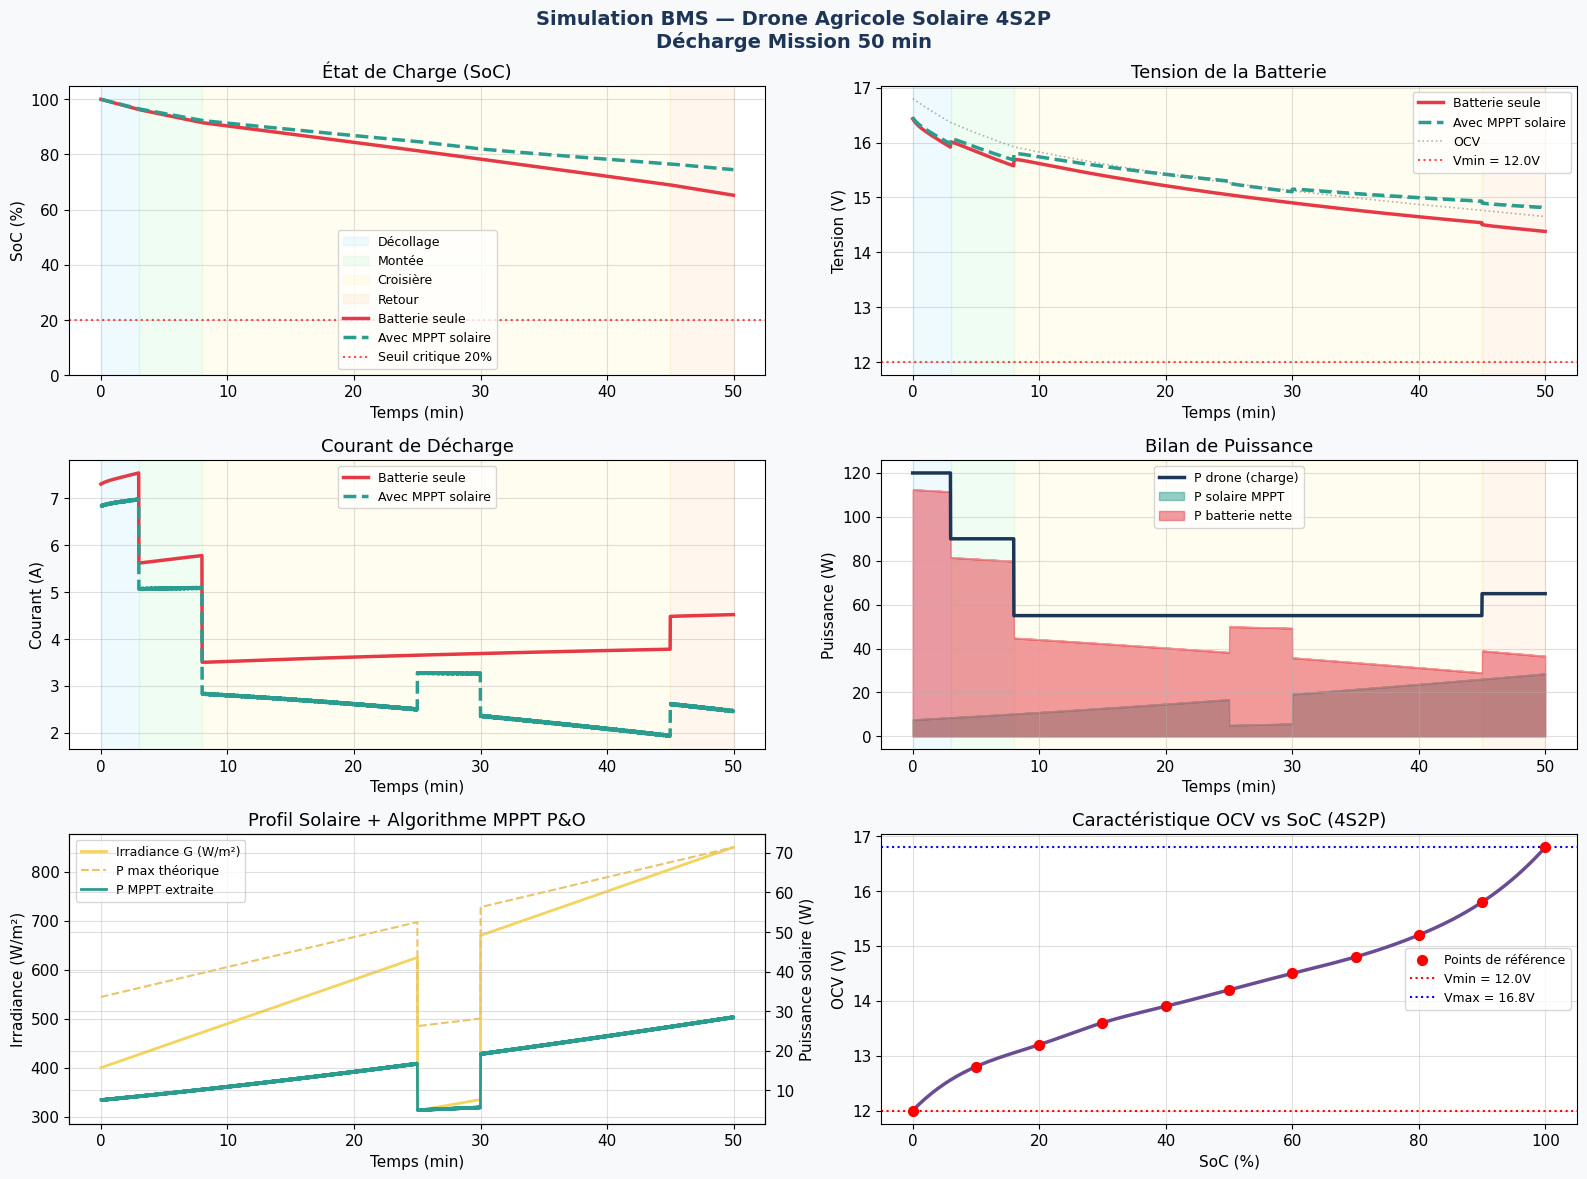

✅ Figure sauvegardée : simulation_decharge_BMS.png


In [8]:
# ============================================================
# FIGURE 1 : DÉCHARGE — BATTERIE SEULE vs AVEC SOLAIRE
# ============================================================

colors = {'decharge': '#E63946', 'solaire': '#2A9D8F', 
          'power': '#F4A261', 'phase': '#457B9D'}

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle('Simulation BMS — Drone Agricole Solaire 4S2P\nDécharge Mission 50 min',
             fontsize=14, fontweight='bold', color='#1D3557')

# Fond coloré par phase
phase_colors = ['#AEE6FF', '#B7F5C1', '#FFF5B1', '#FFD6A5']
phase_boundaries = [0, 3, 8, 45, 50]
phase_names = ['Décollage', 'Montée', 'Croisière', 'Retour']

def add_phases(ax):
    for i, (t_s, t_e, col, name) in enumerate(
        zip(phase_boundaries[:-1], phase_boundaries[1:], phase_colors, phase_names)):
        ax.axvspan(t_s, t_e, alpha=0.2, color=col, label=name if ax==axes[0,0] else '')

# --- SoC comparison ---
ax = axes[0, 0]
add_phases(ax)
ax.plot(t_min, res_discharge['SoC'], color=colors['decharge'], lw=2.5, label='Batterie seule')
ax.plot(t_min, res_solar['SoC'], color=colors['solaire'], lw=2.5, ls='--', label='Avec MPPT solaire')
ax.axhline(20, color='red', ls=':', lw=1.5, alpha=0.7, label='Seuil critique 20%')
ax.set_ylabel('SoC (%)')
ax.set_xlabel('Temps (min)')
ax.set_title('État de Charge (SoC)')
ax.set_ylim(0, 105)
ax.legend(fontsize=9)

# --- Tension batterie ---
ax = axes[0, 1]
add_phases(ax)
ax.plot(t_min, res_discharge['V_bat'], color=colors['decharge'], lw=2.5, label='Batterie seule')
ax.plot(t_min, res_solar['V_bat'], color=colors['solaire'], lw=2.5, ls='--', label='Avec MPPT solaire')
ax.plot(t_min, res_discharge['V_OCV'], color='gray', lw=1.2, ls=':', alpha=0.6, label='OCV')
ax.axhline(V_min, color='red', ls=':', lw=1.5, alpha=0.7, label=f'Vmin = {V_min}V')
ax.set_ylabel('Tension (V)')
ax.set_xlabel('Temps (min)')
ax.set_title('Tension de la Batterie')
ax.legend(fontsize=9)

# --- Courant batterie ---
ax = axes[1, 0]
add_phases(ax)
ax.plot(t_min, res_discharge['I_bat'], color=colors['decharge'], lw=2.5, label='Batterie seule')
ax.plot(t_min, res_solar['I_bat'], color=colors['solaire'], lw=2.5, ls='--', label='Avec MPPT solaire')
ax.set_ylabel('Courant (A)')
ax.set_xlabel('Temps (min)')
ax.set_title('Courant de Décharge')
ax.legend(fontsize=9)

# --- Puissance ---
ax = axes[1, 1]
add_phases(ax)
ax.plot(t_min, P_drone, color='#1D3557', lw=2.5, label='P drone (charge)')
ax.fill_between(t_min, P_solar, alpha=0.5, color=colors['solaire'], label='P solaire MPPT')
ax.fill_between(t_min, res_solar['P_bat'], alpha=0.5, color=colors['decharge'], label='P batterie nette')
ax.set_ylabel('Puissance (W)')
ax.set_xlabel('Temps (min)')
ax.set_title('Bilan de Puissance')
ax.legend(fontsize=9)

# --- Irradiance + MPPT ---
ax = axes[2, 0]
ax2 = ax.twinx()
ax.plot(t_min, G_profile, color='#F4D35E', lw=2, label='Irradiance G (W/m²)')
ax2.plot(t_min, P_solar_ideal, color='#E9C46A', ls='--', lw=1.5, label='P max théorique')
ax2.plot(t_min, P_solar, color=colors['solaire'], lw=2, label='P MPPT extraite')
ax.set_ylabel('Irradiance (W/m²)')
ax2.set_ylabel('Puissance solaire (W)')
ax.set_xlabel('Temps (min)')
ax.set_title('Profil Solaire + Algorithme MPPT P&O')
lines1, lab1 = ax.get_legend_handles_labels()
lines2, lab2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, lab1+lab2, fontsize=9)

# --- Courbe OCV vs SoC ---
ax = axes[2, 1]
soc_plot = np.linspace(0, 1, 200)
ocv_plot = [float(OCV_interp(s)) for s in soc_plot]
ax.plot(soc_plot*100, ocv_plot, color='#6A4C93', lw=2.5)
ax.scatter(SoC_table*100, OCV_table, color='red', s=50, zorder=5, label='Points de référence')
ax.axhline(V_min, color='red', ls=':', lw=1.5, label=f'Vmin = {V_min}V')
ax.axhline(V_max, color='blue', ls=':', lw=1.5, label=f'Vmax = {V_max}V')
ax.set_xlabel('SoC (%)')
ax.set_ylabel('OCV (V)')
ax.set_title('Caractéristique OCV vs SoC (4S2P)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('simulation_decharge_BMS.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure sauvegardée : simulation_decharge_BMS.png")

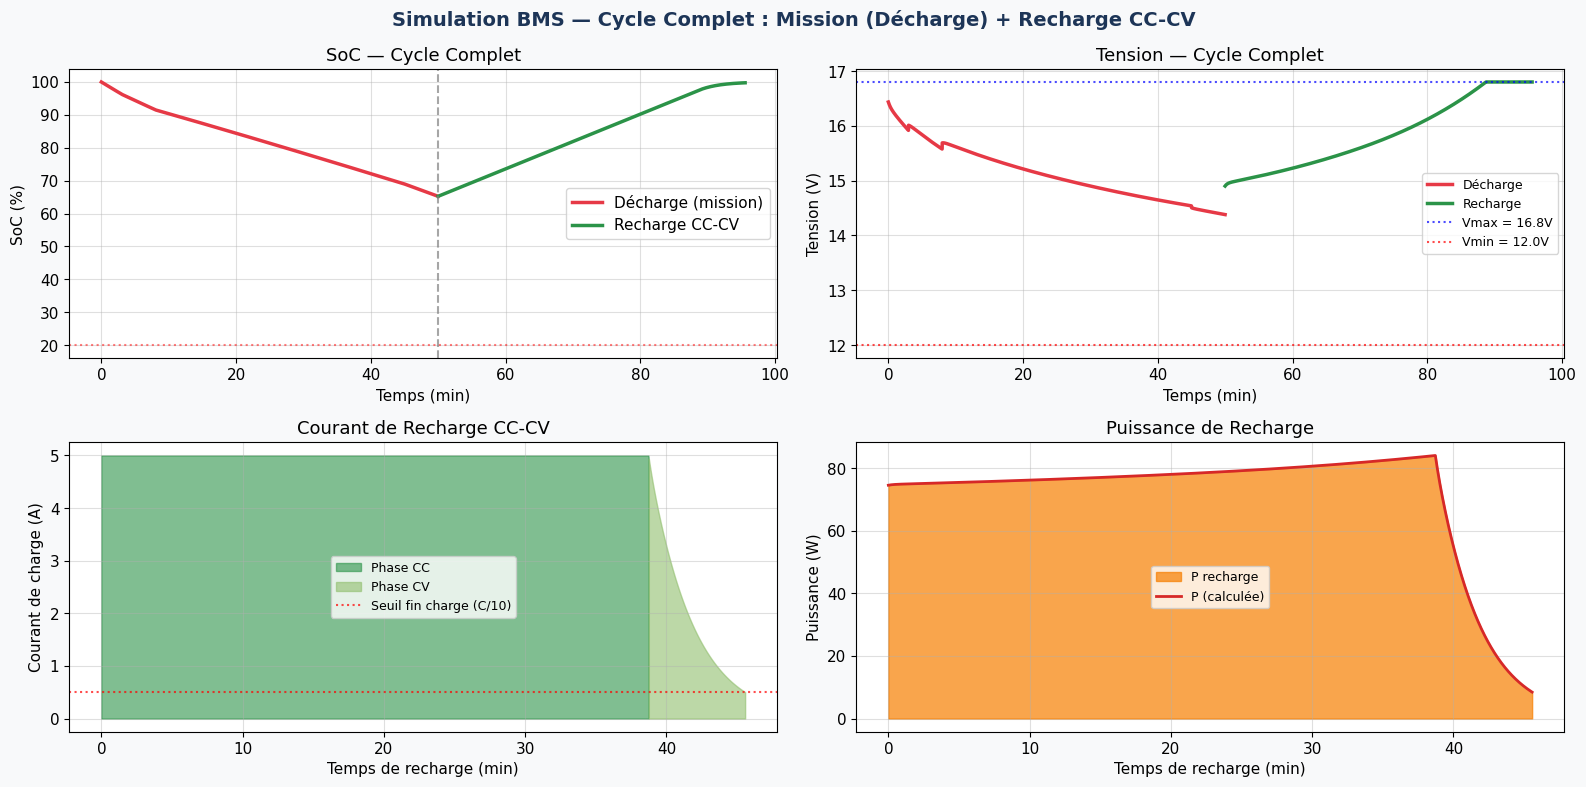

✅ Figure sauvegardée : simulation_recharge_BMS.png


In [9]:
# ============================================================
# FIGURE 2 : CYCLE COMPLET — DÉCHARGE + RECHARGE CC-CV
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle('Simulation BMS — Cycle Complet : Mission (Décharge) + Recharge CC-CV',
             fontsize=14, fontweight='bold', color='#1D3557')

t_charge_min = res_charge['t'] / 60

# --- SoC cycle complet ---
ax = axes[0, 0]
ax.plot(t_min, res_discharge['SoC'], color=colors['decharge'], lw=2.5, label='Décharge (mission)')
# Recharge commence après la mission
t_charge_offset = t_min[-1]
ax.plot(t_charge_offset + t_charge_min, res_charge['SoC'],
        color='#2B9348', lw=2.5, label='Recharge CC-CV')
ax.axvline(t_charge_offset, color='gray', ls='--', lw=1.5, alpha=0.7)
ax.axhline(20, color='red', ls=':', alpha=0.5)
ax.set_ylabel('SoC (%)')
ax.set_xlabel('Temps (min)')
ax.set_title('SoC — Cycle Complet')
ax.legend()

# --- Tension cycle complet ---
ax = axes[0, 1]
ax.plot(t_min, res_discharge['V_bat'], color=colors['decharge'], lw=2.5, label='Décharge')
ax.plot(t_charge_offset + t_charge_min, res_charge['V_bat'],
        color='#2B9348', lw=2.5, label='Recharge')
ax.axhline(V_max, color='blue', ls=':', lw=1.5, alpha=0.7, label=f'Vmax = {V_max}V')
ax.axhline(V_min, color='red', ls=':', lw=1.5, alpha=0.7, label=f'Vmin = {V_min}V')
ax.set_ylabel('Tension (V)')
ax.set_xlabel('Temps (min)')
ax.set_title('Tension — Cycle Complet')
ax.legend(fontsize=9)

# --- Courant recharge détaillé ---
ax = axes[1, 0]
# Trouver la transition CC→CV
I_nominal = 5.0
cc_mask = res_charge['I_bat'] >= 0.99 * I_nominal
cv_mask = ~cc_mask
ax.fill_between(t_charge_min[cc_mask], res_charge['I_bat'][cc_mask],
                alpha=0.6, color='#2B9348', label='Phase CC')
ax.fill_between(t_charge_min[cv_mask], res_charge['I_bat'][cv_mask],
                alpha=0.6, color='#90BE6D', label='Phase CV')
ax.axhline(0.1*I_nominal, color='red', ls=':', lw=1.5, alpha=0.7, label='Seuil fin charge (C/10)')
ax.set_ylabel('Courant de charge (A)')
ax.set_xlabel('Temps de recharge (min)')
ax.set_title('Courant de Recharge CC-CV')
ax.legend(fontsize=9)

# --- Puissance recharge ---
ax = axes[1, 1]
ax.fill_between(t_charge_min, res_charge['P_charge'],
                alpha=0.7, color='#F77F00', label='P recharge')
ax.plot(t_charge_min, res_charge['V_bat'] * res_charge['I_bat'],
        color='#D62828', lw=2, label='P (calculée)')
ax.set_ylabel('Puissance (W)')
ax.set_xlabel('Temps de recharge (min)')
ax.set_title('Puissance de Recharge')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('simulation_recharge_BMS.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure sauvegardée : simulation_recharge_BMS.png")

In [10]:
# ============================================================
# TABLEAU DE BORD FINAL
# ============================================================

print("="*60)
print(" TABLEAU DE BORD — SIMULATION BMS DRONE AGRICOLE")
print("="*60)
print(f"\n📦 BATTERIE")
print(f"  Configuration  : {N_series}S{N_parallel}P")
print(f"  Capacité       : {Q_nom} Ah  |  Énergie : {E_nom} Wh")
print(f"  Tension        : {V_min}V (min) — {V_nom}V (nom) — {V_max}V (max)")

print(f"\n✈️  MISSION (50 min — batterie seule)")
print(f"  SoC initial    : 100.0 %")
print(f"  SoC final      : {res_discharge['SoC'][-1]:.1f} %")
print(f"  ΔSoC consommé  : {100-res_discharge['SoC'][-1]:.1f} %")
print(f"  Tension min    : {res_discharge['V_bat'].min():.2f} V")
print(f"  Courant max    : {res_discharge['I_bat'].max():.2f} A")

print(f"\n☀️  MISSION (50 min — avec MPPT solaire)")
print(f"  SoC final      : {res_solar['SoC'][-1]:.1f} %")
print(f"  ΔSoC consommé  : {100-res_solar['SoC'][-1]:.1f} %")
print(f"  Énergie solaire: {E_solaire_recup:.1f} Wh récupérés")
print(f"  Gain endurance : ~{E_solaire_recup/np.mean(P_drone)*60:.0f} min supplémentaires")

print(f"\n🔋 RECHARGE CC-CV (depuis {SoC_apres_mission:.1f}%)")
print(f"  SoC final      : {res_charge['SoC'][-1]:.1f} %")
print(f"  Durée          : {res_charge['t'][-1]/60:.0f} min")
print(f"  Courant CC     : 5.0 A (0.5C)")
print("="*60)

 TABLEAU DE BORD — SIMULATION BMS DRONE AGRICOLE

📦 BATTERIE
  Configuration  : 4S2P
  Capacité       : 10.0 Ah  |  Énergie : 148.0 Wh
  Tension        : 12.0V (min) — 14.8V (nom) — 16.8V (max)

✈️  MISSION (50 min — batterie seule)
  SoC initial    : 100.0 %
  SoC final      : 65.2 %
  ΔSoC consommé  : 34.8 %
  Tension min    : 14.38 V
  Courant max    : 7.54 A

☀️  MISSION (50 min — avec MPPT solaire)
  SoC final      : 74.5 %
  ΔSoC consommé  : 25.5 %
  Énergie solaire: 13.3 Wh récupérés
  Gain endurance : ~13 min supplémentaires

🔋 RECHARGE CC-CV (depuis 65.2%)
  SoC final      : 99.8 %
  Durée          : 46 min
  Courant CC     : 5.0 A (0.5C)


---
## 7. Analyse Cycle de Vie Énergétique (LCE) & Empreinte Carbone CO₂

> **Référence méthodologique** : ISO 14067 — *Product Carbon Footprint*, GHG Protocol (Scope 1/2/3), et approche LCA (Life Cycle Assessment) du cours *Energy Transition and Decarbonization*.

### Périmètre de l'analyse
| Scope | Sources retenues |
|-------|------------------|
| **Scope 1** | Émissions directes (ici nulles : drone électrique) |
| **Scope 2** | Électricité consommée pour la recharge de la batterie |
| **Scope 3** | Fabrication de la batterie Li-ion (extraction matériaux, production cellules) |

### Indicateurs calculés
- **LCE** (Life Cycle Energy) : énergie totale mobilisée sur la durée de vie de la batterie [kWh]
- **Carbon Footprint** : empreinte CO₂ totale sur la durée de vie [kg CO₂eq]
- **Carbon Intensity** : émissions par mission [g CO₂eq / mission]


In [11]:
# ============================================================
# 7a. PARAMÈTRES CYCLE DE VIE (LCE & Empreinte Carbone)
# ============================================================

# ---- Facteurs d'émission (kg CO2eq / kWh) ----
# Source : IEA World Energy Outlook — mix réseau Tunisie ≈ 0.58 kg CO2/kWh
# (à adapter selon le pays / mix énergétique réel)
FE_grid      = 0.58    # kg CO2eq / kWh — électricité réseau (Scope 2)

# Facteur solaire : émissions sur cycle de vie panneau PV
# Source : IPCC AR6 — médiane technologie Si cristallin ≈ 0.041 kg CO2eq/kWh
FE_solar     = 0.041   # kg CO2eq / kWh — solaire PV (amortissement panneau)

# ---- Durée de vie batterie ----
N_cycles     = 500     # Nombre de cycles complets (Li-ion 4S2P, décharge 80%)
# → Durée de vie totale estimée : N_cycles missions

# ---- Énergie embarquée fabrication batterie (Scope 3) ----
# Source : Majeau-Bettez et al. (2011) — ~250 Wh/Wh batterie Li-ion
# (énergie grise de production cellule)
EE_batterie  = 250.0   # Wh d'énergie primaire / Wh de capacité batterie
FE_bat_mfg   = 0.120   # kg CO2eq / Wh capacité batterie (fabrication)
# → Carbon intensity fabrication ≈ 120 g CO2eq / Wh capacité

# ---- Rendement chargeur ----
eta_charge   = 0.90    # Rendement chargeur (CC-CV typique)

print("✅ Paramètres LCE / Empreinte carbone définis")
print(f"  Facteur émission réseau : {FE_grid} kg CO2eq/kWh")
print(f"  Facteur émission solaire: {FE_solar} kg CO2eq/kWh")
print(f"  Durée de vie batterie   : {N_cycles} cycles")
print(f"  Énergie grise batterie  : {EE_batterie} Wh/Wh")


✅ Paramètres LCE / Empreinte carbone définis
  Facteur émission réseau : 0.58 kg CO2eq/kWh
  Facteur émission solaire: 0.041 kg CO2eq/kWh
  Durée de vie batterie   : 500 cycles
  Énergie grise batterie  : 250.0 Wh/Wh


In [12]:
# ============================================================
# 7b. CALCUL LCE — LIFE CYCLE ENERGY [kWh]
# ============================================================

# --- Énergie par mission (décharge batterie + recharge) ---
E_decharge_mission   = np.trapezoid(res_discharge['P_bat'], t_arr) / 3600   # Wh — batterie seule
E_solaire_mission    = np.trapezoid(res_solar['P_solar'],   t_arr) / 3600   # Wh — apport solaire
E_decharge_solar_mis = np.trapezoid(res_solar['P_bat'],     t_arr) / 3600   # Wh — batterie (avec solaire)

# Énergie réseau pour recharger (après mission sans solaire)
E_recharge_reseau    = np.trapezoid(res_charge['P_charge'], res_charge['t']) / 3600   # Wh — fourni au chargeur
E_recharge_grille    = E_recharge_reseau / eta_charge                              # Wh — tiré du réseau

# --- LCE sur la durée de vie (N_cycles missions) ---
# LCE = Énergie fabrication + Énergie recharge réseau cumulée
E_fabrication_kWh    = (EE_batterie * E_nom) / 1000          # kWh — énergie grise production batterie
E_recharge_totale    = (E_recharge_grille * N_cycles) / 1000  # kWh — énergie réseau sur durée de vie
E_solaire_totale     = (E_solaire_mission * N_cycles) / 1000  # kWh — solaire sur durée de vie

LCE_sans_solaire     = E_fabrication_kWh + E_recharge_totale  # kWh
LCE_avec_solaire     = E_fabrication_kWh + (E_recharge_totale - E_solaire_totale)  # kWh (réduit par solaire)
LCE_avec_solaire     = max(LCE_avec_solaire, E_fabrication_kWh)  # plancher

print("LCE — Life Cycle Energy :")
print(f"  Énergie grise fabrication batterie : {E_fabrication_kWh:.1f} kWh")
print(f"  Énergie réseau / mission           : {E_recharge_grille/1000:.3f} kWh")
print(f"  Énergie réseau totale ({N_cycles} cycles) : {E_recharge_totale:.1f} kWh")
print(f"  Apport solaire total               : {E_solaire_totale:.1f} kWh")
print(f"")
print(f"  LCE (sans solaire)  = {LCE_sans_solaire:.1f} kWh")
print(f"  LCE (avec solaire)  = {LCE_avec_solaire:.1f} kWh")
print(f"  Réduction LCE grâce au solaire : {(1-LCE_avec_solaire/LCE_sans_solaire)*100:.1f} %")


LCE — Life Cycle Energy :
  Énergie grise fabrication batterie : 37.0 kWh
  Énergie réseau / mission           : 0.060 kWh
  Énergie réseau totale (500 cycles) : 30.2 kWh
  Apport solaire total               : 6.7 kWh

  LCE (sans solaire)  = 67.2 kWh
  LCE (avec solaire)  = 60.5 kWh
  Réduction LCE grâce au solaire : 9.9 %


In [13]:
# ============================================================
# 7c. CALCUL EMPREINTE CARBONE CO₂ [kg CO2eq]
# ============================================================

# --- Scope 3 : Fabrication batterie ---
CO2_fabrication   = FE_bat_mfg * E_nom * 1000 / 1000   # kg CO2eq
# (FE_bat_mfg en kg/Wh * E_nom en Wh = kg CO2eq)
CO2_fabrication   = FE_bat_mfg * E_nom                  # kg CO2eq

# --- Scope 2 : Recharge réseau (sans solaire) ---
CO2_recharge_tot  = (E_recharge_grille / 1000) * FE_grid * N_cycles   # kg CO2eq

# --- Scope 2 solaire : CO2 amortissement panneau PV ---
CO2_solaire_tot   = (E_solaire_mission / 1000) * FE_solar * N_cycles   # kg CO2eq

# --- Empreinte totale sur la durée de vie ---
CF_sans_solaire   = CO2_fabrication + CO2_recharge_tot              # kg CO2eq
CF_avec_solaire   = CO2_fabrication + CO2_solaire_tot + \
                    ((E_recharge_grille - E_solaire_mission) / 1000 * FE_grid * N_cycles)

# --- Intensité carbone par mission ---
CF_par_mission_sans = CF_sans_solaire / N_cycles * 1000   # g CO2eq / mission
CF_par_mission_avec = CF_avec_solaire  / N_cycles * 1000  # g CO2eq / mission

# --- Intensité carbone par kWh délivré ---
E_utile_totale    = (E_decharge_mission / 1000) * N_cycles   # kWh utiles délivrés
CI_sans_solaire   = CF_sans_solaire / E_utile_totale * 1000  # g CO2eq / kWh utile
CI_avec_solaire   = CF_avec_solaire / E_utile_totale * 1000  # g CO2eq / kWh utile

print("Empreinte Carbone CO₂ sur durée de vie (%d cycles) :" % N_cycles)
print(f"")
print(f"  [Scope 3] CO2 fabrication batterie : {CO2_fabrication:.2f} kg CO2eq")
print(f"  [Scope 2] CO2 recharge réseau tot. : {CO2_recharge_tot:.2f} kg CO2eq")
print(f"  [Scope 2☀] CO2 solaire PV (LCA)   : {CO2_solaire_tot:.2f} kg CO2eq")
print(f"")
print(f"  ➡ Empreinte totale SANS solaire : {CF_sans_solaire:.2f} kg CO2eq")
print(f"  ➡ Empreinte totale AVEC solaire : {CF_avec_solaire:.2f} kg CO2eq")
print(f"  Réduction CO2 grâce au solaire  : {(1-CF_avec_solaire/CF_sans_solaire)*100:.1f} %")
print(f"")
print(f"  Intensité carbone / mission (sans solaire) : {CF_par_mission_sans:.0f} g CO2eq")
print(f"  Intensité carbone / mission (avec solaire) : {CF_par_mission_avec:.0f} g CO2eq")
print(f"  Intensité carbone / kWh utile (sans sol.)  : {CI_sans_solaire:.0f} g CO2eq/kWh")
print(f"  Intensité carbone / kWh utile (avec sol.)  : {CI_avec_solaire:.0f} g CO2eq/kWh")


Empreinte Carbone CO₂ sur durée de vie (500 cycles) :

  [Scope 3] CO2 fabrication batterie : 17.76 kg CO2eq
  [Scope 2] CO2 recharge réseau tot. : 17.50 kg CO2eq
  [Scope 2☀] CO2 solaire PV (LCA)   : 0.27 kg CO2eq

  ➡ Empreinte totale SANS solaire : 35.26 kg CO2eq
  ➡ Empreinte totale AVEC solaire : 31.67 kg CO2eq
  Réduction CO2 grâce au solaire  : 10.2 %

  Intensité carbone / mission (sans solaire) : 71 g CO2eq
  Intensité carbone / mission (avec solaire) : 63 g CO2eq
  Intensité carbone / kWh utile (sans sol.)  : 1336 g CO2eq/kWh
  Intensité carbone / kWh utile (avec sol.)  : 1199 g CO2eq/kWh


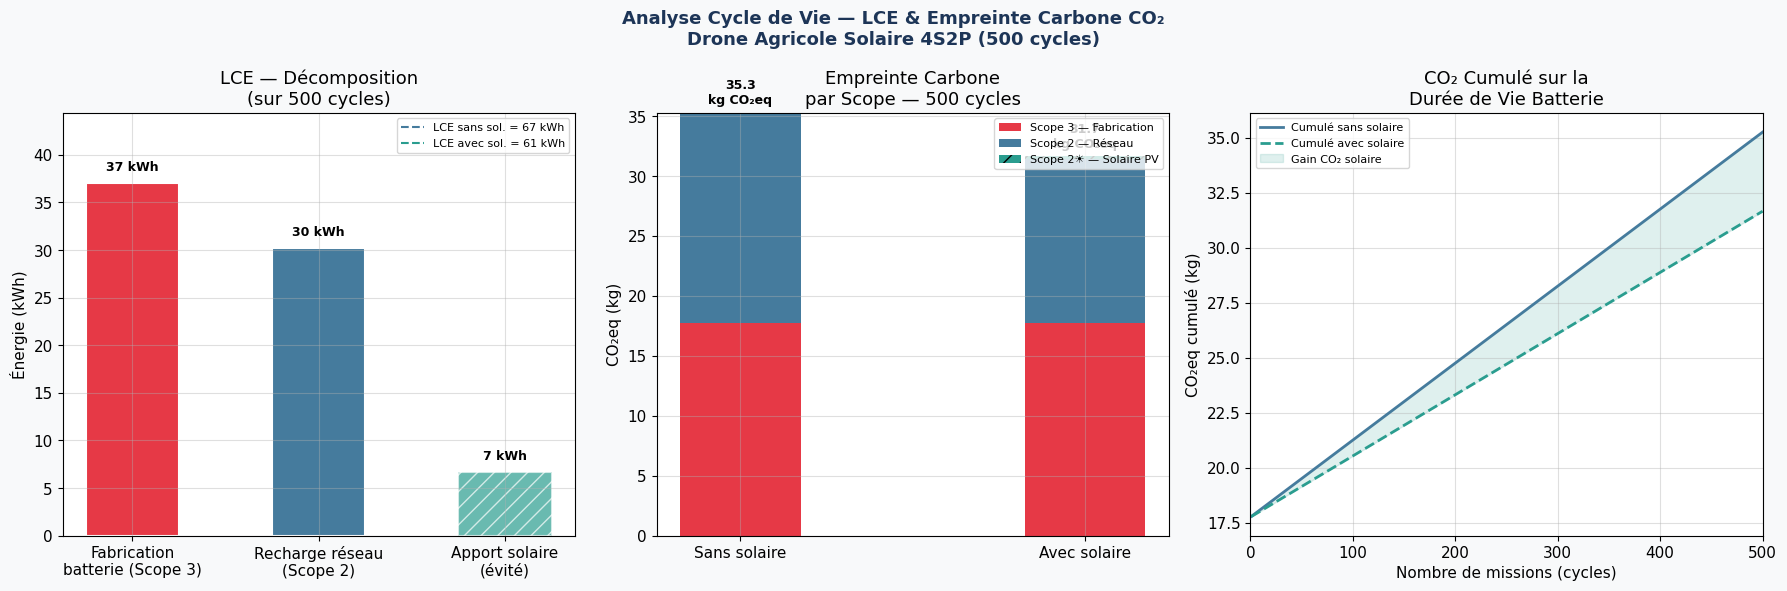

✅ Figure sauvegardée : LCE_carbon_footprint_drone.png


In [14]:
# ============================================================
# 7d. VISUALISATION LCE & EMPREINTE CARBONE
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Analyse Cycle de Vie — LCE & Empreinte Carbone CO₂\nDrone Agricole Solaire 4S2P (500 cycles)',
             fontsize=13, fontweight='bold', color='#1D3557')

# Palette cohérente
c_bat   = '#E63946'   # fabrication
c_grid  = '#457B9D'   # réseau
c_solar = '#2A9D8F'   # solaire

# --- 1. Décomposition LCE ---
ax = axes[0]
labels_lce = ['Fabrication\nbatterie (Scope 3)', 'Recharge réseau\n(Scope 2)', 'Apport solaire\n(évité)']
vals_lce   = [E_fabrication_kWh, E_recharge_totale, -E_solaire_totale]
colors_lce = [c_bat, c_grid, c_solar]
bars = ax.bar(labels_lce, [abs(v) for v in vals_lce], color=colors_lce, width=0.5, edgecolor='white', linewidth=1.5)
# Hachures pour "évité"
bars[2].set_hatch('//')
bars[2].set_alpha(0.7)
for bar, val in zip(bars, [E_fabrication_kWh, E_recharge_totale, E_solaire_totale]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.0f} kWh',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylabel('Énergie (kWh)')
ax.set_title('LCE — Décomposition\n(sur 500 cycles)')
ax.set_ylim(0, max(E_fabrication_kWh, E_recharge_totale) * 1.2)
# Ligne LCE totale
ax.axhline(LCE_sans_solaire, color=c_grid, ls='--', lw=1.5, label=f'LCE sans sol. = {LCE_sans_solaire:.0f} kWh')
ax.axhline(LCE_avec_solaire, color=c_solar, ls='--', lw=1.5, label=f'LCE avec sol. = {LCE_avec_solaire:.0f} kWh')
ax.legend(fontsize=8)

# --- 2. Empreinte carbone — décomposition Scope ---
ax = axes[1]
categories = ['Sans solaire', 'Avec solaire']
scope3_vals  = [CO2_fabrication, CO2_fabrication]
scope2_grid  = [CO2_recharge_tot,
                (E_recharge_grille - E_solaire_mission) / 1000 * FE_grid * N_cycles]
scope2_solar = [0, CO2_solaire_tot]

x = np.arange(len(categories))
w = 0.35
b1 = ax.bar(x, scope3_vals, w, label='Scope 3 — Fabrication', color=c_bat)
b2 = ax.bar(x, scope2_grid, w, bottom=scope3_vals, label='Scope 2 — Réseau', color=c_grid)
b3 = ax.bar(x, scope2_solar, w,
            bottom=[s3 + s2 for s3, s2 in zip(scope3_vals, scope2_grid)],
            label='Scope 2☀ — Solaire PV', color=c_solar, hatch='//')

totals = [CF_sans_solaire, CF_avec_solaire]
for xi, tot in zip(x, totals):
    ax.text(xi, tot + 0.5, f'{tot:.1f}\nkg CO₂eq', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel('CO₂eq (kg)')
ax.set_title('Empreinte Carbone\npar Scope — 500 cycles')
ax.legend(fontsize=8, loc='upper right')

# --- 3. Intensité carbone par mission ---
ax = axes[2]
missions = np.arange(1, N_cycles + 1)

# CO2 cumulé par mission (avec amortissement fabrication)
CO2_cum_sans = CO2_fabrication + (E_recharge_grille / 1000) * FE_grid * missions
CO2_cum_avec = CO2_fabrication + CO2_solaire_tot * missions / N_cycles + \
               ((E_recharge_grille - E_solaire_mission) / 1000 * FE_grid) * missions

# Intensité marginale
CI_marg_sans = np.gradient(CO2_cum_sans) * 1000   # g CO2eq / mission
CI_marg_avec = np.gradient(CO2_cum_avec) * 1000

ax.plot(missions, CO2_cum_sans, color=c_grid, lw=2, label='Cumulé sans solaire')
ax.plot(missions, CO2_cum_avec, color=c_solar, lw=2, ls='--', label='Cumulé avec solaire')
ax.fill_between(missions, CO2_cum_avec, CO2_cum_sans, alpha=0.15, color=c_solar, label='Gain CO₂ solaire')
ax.set_xlabel('Nombre de missions (cycles)')
ax.set_ylabel('CO₂eq cumulé (kg)')
ax.set_title('CO₂ Cumulé sur la\nDurée de Vie Batterie')
ax.legend(fontsize=8)
ax.set_xlim(0, N_cycles)

plt.tight_layout()
plt.savefig('LCE_carbon_footprint_drone.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure sauvegardée : LCE_carbon_footprint_drone.png")


In [15]:
# ============================================================
# 7e. TABLEAU DE BORD — LCE & EMPREINTE CARBONE
# ============================================================

print("="*65)
print(" BILAN LCE & EMPREINTE CARBONE CO₂ — DRONE AGRICOLE SOLAIRE")
print("="*65)
print(f"  Batterie          : {N_series}S{N_parallel}P Li-ion | {E_nom} Wh | {N_cycles} cycles")
print(f"  Facteur réseau    : {FE_grid} kg CO2eq/kWh  (mix Tunisie)")
print(f"  Facteur solaire   : {FE_solar} kg CO2eq/kWh (amortis. PV)")
print()
print(" LIFE CYCLE ENERGY (LCE)")
print(f"  Énergie grise fabrication   : {E_fabrication_kWh:>8.1f} kWh")
print(f"  Énergie réseau (500 cycles) : {E_recharge_totale:>8.1f} kWh")
print(f"  LCE sans solaire            : {LCE_sans_solaire:>8.1f} kWh")
print(f"  LCE avec solaire            : {LCE_avec_solaire:>8.1f} kWh")
print(f"  ↓ Réduction LCE solaire     : {(1-LCE_avec_solaire/LCE_sans_solaire)*100:>7.1f} %")
print()
print(" EMPREINTE CARBONE CO₂ (Carbon Footprint)")
print(f"  CO2 fabrication (Scope 3)   : {CO2_fabrication:>8.2f} kg CO2eq")
print(f"  CO2 réseau total (Scope 2)  : {CO2_recharge_tot:>8.2f} kg CO2eq")
print(f"  CO2 total SANS solaire      : {CF_sans_solaire:>8.2f} kg CO2eq")
print(f"  CO2 total AVEC solaire      : {CF_avec_solaire:>8.2f} kg CO2eq")
print(f"  ↓ Réduction CO2 solaire     : {(1-CF_avec_solaire/CF_sans_solaire)*100:>7.1f} %")
print()
print(" INTENSITÉ CARBONE")
print(f"  CO2 / mission (sans sol.)   : {CF_par_mission_sans:>8.0f} g CO2eq")
print(f"  CO2 / mission (avec sol.)   : {CF_par_mission_avec:>8.0f} g CO2eq")
print(f"  CO2 / kWh utile (sans sol.) : {CI_sans_solaire:>8.0f} g CO2eq/kWh")
print(f"  CO2 / kWh utile (avec sol.) : {CI_avec_solaire:>8.0f} g CO2eq/kWh")
print("="*65)


 BILAN LCE & EMPREINTE CARBONE CO₂ — DRONE AGRICOLE SOLAIRE
  Batterie          : 4S2P Li-ion | 148.0 Wh | 500 cycles
  Facteur réseau    : 0.58 kg CO2eq/kWh  (mix Tunisie)
  Facteur solaire   : 0.041 kg CO2eq/kWh (amortis. PV)

 LIFE CYCLE ENERGY (LCE)
  Énergie grise fabrication   :     37.0 kWh
  Énergie réseau (500 cycles) :     30.2 kWh
  LCE sans solaire            :     67.2 kWh
  LCE avec solaire            :     60.5 kWh
  ↓ Réduction LCE solaire     :     9.9 %

 EMPREINTE CARBONE CO₂ (Carbon Footprint)
  CO2 fabrication (Scope 3)   :    17.76 kg CO2eq
  CO2 réseau total (Scope 2)  :    17.50 kg CO2eq
  CO2 total SANS solaire      :    35.26 kg CO2eq
  CO2 total AVEC solaire      :    31.67 kg CO2eq
  ↓ Réduction CO2 solaire     :    10.2 %

 INTENSITÉ CARBONE
  CO2 / mission (sans sol.)   :       71 g CO2eq
  CO2 / mission (avec sol.)   :       63 g CO2eq
  CO2 / kWh utile (sans sol.) :     1336 g CO2eq/kWh
  CO2 / kWh utile (avec sol.) :     1199 g CO2eq/kWh
